# Behavioral Feature Engineering


In [ ]:
import numpy as np

np.random.seed(42)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Students Social Media Addiction.csv to Students Social Media Addiction.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Students Social Media Addiction.csv")

In [ ]:
df['Risk_Score'] = (
    0.35*(df['Addicted_Score']/9)
    + 0.25*(df['Avg_Daily_Usage_Hours']/8.5)
    + 0.20*(df['Conflicts_Over_Social_Media']/5)
    + 0.10*(1-df['Sleep_Hours_Per_Night']/10)
    + 0.10*(1-df['Mental_Health_Score']/10)
)

In [ ]:


df['App_Switch_Frequency'] = (
    20 +
    df['Risk_Score'] * 220 +
    np.random.normal(0, 10, len(df))
)

df['App_Switch_Frequency'] = (
    df['App_Switch_Frequency']
    .clip(20, 250)
    .round()
)

In [ ]:
df[['Risk_Score',
    'App_Switch_Frequency',
    'Addicted_Score']].head()

,Risk_Score,App_Switch_Frequency,Addicted_Score
0,0.659052,170.0,8
1,0.223431,68.0,3
2,0.786471,200.0,9
3,0.343791,111.0,4
4,0.564575,142.0,7


In [ ]:
df['Notification_Response_Time'] = (
    600*(1-df['Risk_Score']) +
    np.random.normal(0,30,len(df))
)

df['Notification_Response_Time'] = (
    df['Notification_Response_Time']
    .clip(5,600)
    .round()
)

In [ ]:
df[['Risk_Score',
    'Notification_Response_Time',
    'Addicted_Score']].head()

,Risk_Score,Notification_Response_Time,Addicted_Score
0,0.659052,223.0,8
1,0.223431,428.0,3
2,0.786471,181.0,9
3,0.343791,331.0,4
4,0.564575,312.0,7


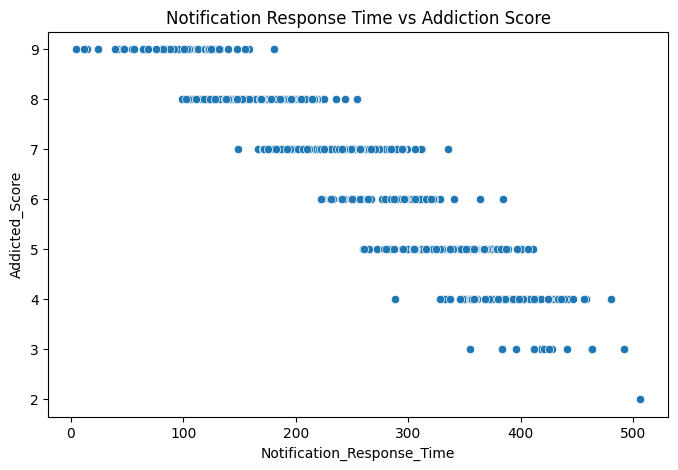

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Notification_Response_Time',
    y='Addicted_Score'
)

plt.title("Notification Response Time vs Addiction Score")
plt.show()

In [ ]:
df['Relapse_Frequency'] = (
    2 +
    df['Risk_Score']*25 +
    np.random.normal(0,2,len(df))
)

df['Relapse_Frequency'] = (
    df['Relapse_Frequency']
    .clip(1,30)
    .round()
)

In [ ]:
df[['Risk_Score',
    'Notification_Response_Time',
    'Relapse_Frequency',
    'Addicted_Score']].head()

,Risk_Score,Notification_Response_Time,Relapse_Frequency,Addicted_Score
0,0.659052,223.0,21.0,8
1,0.223431,428.0,9.0,3
2,0.786471,181.0,23.0,9
3,0.343791,331.0,15.0,4
4,0.564575,312.0,15.0,7


In [ ]:
df['Short_Form_Content_Ratio'] = (
    0.15 +
    df['Risk_Score']*0.8 +
    np.random.normal(0,0.05,len(df))
)

df['Short_Form_Content_Ratio'] = (
    df['Short_Form_Content_Ratio']
    .clip(0,1)
)

In [ ]:
df['Attention_Recovery_Time'] = (
    2 +
    df['Risk_Score']*35 +
    np.random.normal(0,2,len(df))
)

df['Attention_Recovery_Time'] = (
    df['Attention_Recovery_Time']
    .clip(2,40)
    .round()
)

In [ ]:
df['Late_Night_Usage_Index'] = (
    0.05 +
    df['Risk_Score']*0.7 +
    np.random.normal(0,0.04,len(df))
)

df['Late_Night_Usage_Index'] = (
    df['Late_Night_Usage_Index']
    .clip(0,1)
)

In [ ]:
df['Usage_Escalation_Rate'] = (
    -0.2 +
    df['Risk_Score']*0.7 +
    np.random.normal(0,0.05,len(df))
)

df['Usage_Escalation_Rate'] = (
    df['Usage_Escalation_Rate']
    .clip(-0.2,0.5)
)

In [ ]:
avg_session = (
    10 +
    df['Risk_Score']*60 +
    np.random.normal(0,5,len(df))
)

max_session = (
    20 +
    df['Risk_Score']*180 +
    np.random.normal(0,10,len(df))
)

df['Session_Binge_Score'] = (
    (avg_session*max_session)/100
)

df['Session_Binge_Score'] = (
    df['Session_Binge_Score']
    .clip(5,250)
)

In [ ]:
new_features = [
    'App_Switch_Frequency',
    'Notification_Response_Time',
    'Relapse_Frequency',
    'Short_Form_Content_Ratio',
    'Attention_Recovery_Time',
    'Late_Night_Usage_Index',
    'Usage_Escalation_Rate',
    'Session_Binge_Score'
]

df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
App_Switch_Frequency,705.0,147.043972,34.438426,58.000000,120.000000,149.000000,173.000000,227.000000
Notification_Response_Time,705.0,255.614184,95.623010,5.000000,185.000000,252.000000,329.000000,506.000000
Relapse_Frequency,705.0,16.529078,4.188671,6.000000,14.000000,17.000000,20.000000,27.000000
Short_Form_Content_Ratio,705.0,0.613873,0.131795,0.296539,0.515891,0.621623,0.712569,0.972043
Attention_Recovery_Time,705.0,22.185816,5.640088,6.000000,18.000000,23.000000,26.000000,36.000000
Late_Night_Usage_Index,705.0,0.452904,0.113051,0.174325,0.364401,0.460631,0.532881,0.723633
Usage_Escalation_Rate,705.0,0.202304,0.113156,-0.104099,0.118664,0.202819,0.286229,0.500000
Session_Binge_Score,705.0,57.634327,24.307299,7.463106,37.377807,55.404057,76.364316,130.188207


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['ASF_norm','RF_norm','SBS_norm']] = scaler.fit_transform(
    df[['App_Switch_Frequency',
        'Relapse_Frequency',
        'Session_Binge_Score']]
)

In [ ]:
df['Brain_Rot_Index'] = (
    0.30*df['Short_Form_Content_Ratio']
    +0.20*df['Late_Night_Usage_Index']
    +0.20*df['RF_norm']
    +0.15*df['ASF_norm']
    +0.15*df['SBS_norm']
)

df['Brain_Rot_Index'] = (
    df['Brain_Rot_Index']*100
)

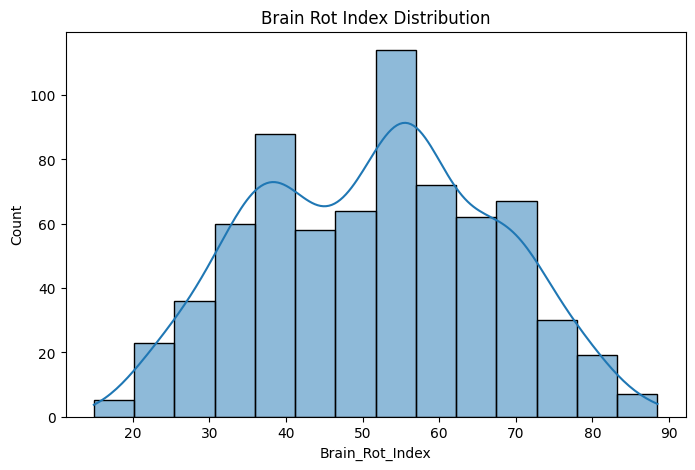

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Brain_Rot_Index'],
    kde=True
)

plt.title("Brain Rot Index Distribution")
plt.show()

In [ ]:
df['Brain_Rot_Index'].describe()

,Brain_Rot_Index
count,705.000000
mean,51.537420
std,15.290016
min,14.911426
25%,38.530272
50%,52.787736
75%,63.389954
max,88.504168


# Behavioral Persona Discovery using KMeans Clustering

In [ ]:
cluster_features = [
    'App_Switch_Frequency',
    'Notification_Response_Time',
    'Relapse_Frequency',
    'Short_Form_Content_Ratio',
    'Attention_Recovery_Time',
    'Late_Night_Usage_Index',
    'Session_Binge_Score',
    'Brain_Rot_Index'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(
    df[cluster_features]
)

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,10):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

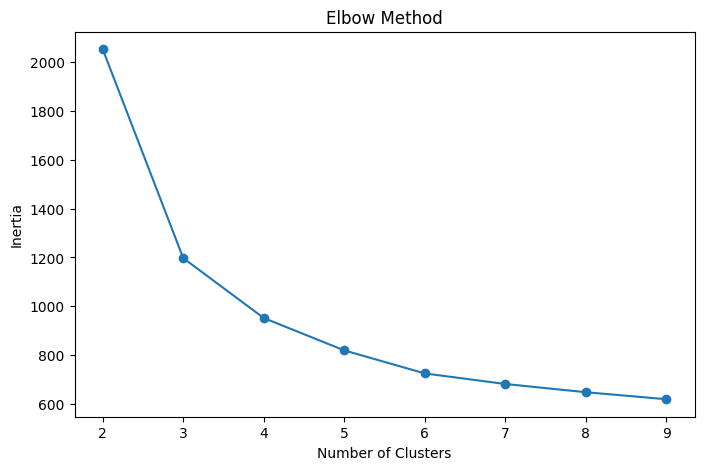

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,10),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,98
1,175
2,175
3,257


In [ ]:
cluster_profile = (
    df.groupby('Cluster')[[
        'App_Switch_Frequency',
        'Notification_Response_Time',
        'Relapse_Frequency',
        'Short_Form_Content_Ratio',
        'Attention_Recovery_Time',
        'Late_Night_Usage_Index',
        'Session_Binge_Score',
        'Brain_Rot_Index',
        'Addicted_Score'
    ]]
    .mean()
    .round(2)
)

cluster_profile

,App_Switch_Frequency,Notification_Response_Time,Relapse_Frequency,Short_Form_Content_Ratio,Attention_Recovery_Time,Late_Night_Usage_Index,Session_Binge_Score,Brain_Rot_Index,Addicted_Score
Cluster,,,,,,,,,
0,95.05,396.86,10.57,0.42,13.42,0.29,25.23,28.14,3.92
1,189.79,137.37,21.32,0.77,28.81,0.59,89.32,71.35,8.30
2,121.26,327.71,13.71,0.52,18.36,0.37,38.73,39.74,5.17
3,155.32,233.18,17.46,0.64,23.62,0.48,61.28,55.00,6.99


In [ ]:
persona_map = {
    0: "Healthy Users",
    2: "Casual Users",
    3: "Frequent Scrollers",
    1: "Doom Scrollers"
}

df["Persona"] = df["Cluster"].map(persona_map)

## PCA Visualization

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

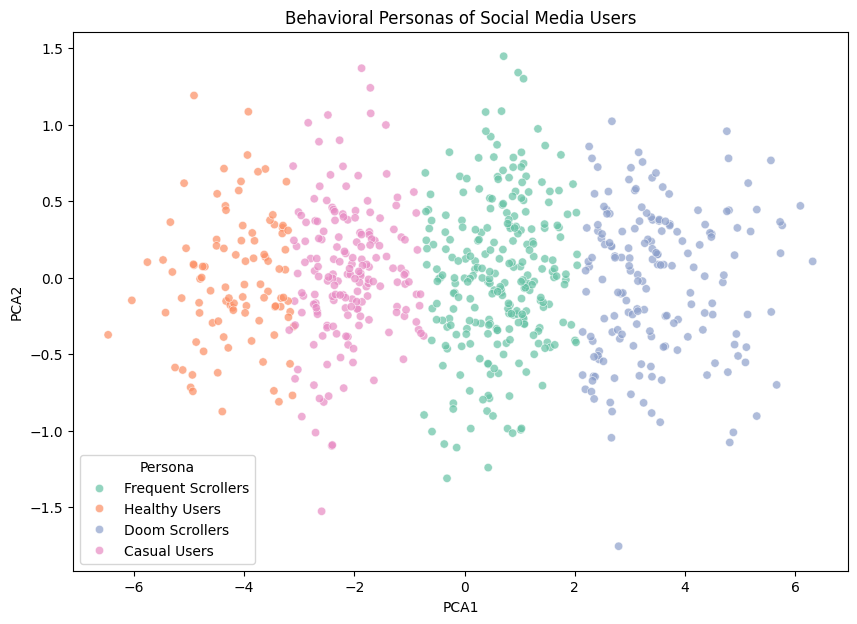

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Persona',
    palette='Set2',
    alpha=0.7
)

plt.title("Behavioral Personas of Social Media Users")
plt.show()

In [ ]:
df.to_csv(
    "enriched_social_media_dataset.csv",
    index=False
)

In [ ]:
import os

os.listdir()

['.config',
 'enriched_social_media_dataset.csv',
 'Students Social Media Addiction.csv',
 'sample_data']

In [ ]:
from google.colab import files

files.download(
    "enriched_social_media_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>